# ARAŞTIRMA YÖNTEM VE TASARIMLARI FİNAL PROJESİ
## Konu: Kar Lastiği Markalarının Konfor ve Güvenlik Açısından Kıyaslanması
**Hazırlayanlar:** * 360125051 - MUSTAFA ERAYDIN
* 360125050 - ŞEVKİ BİLGİÇ

### MP1: Problem ve Hipotez
**Araştırma Problemi:** Tüketicilerin kar lastiği alırken güvenlik ve konfor arasında seçim yapmak zorunda kalması ve markaların bu dengeyi ne kadar sağladığının belirsizliği.
**Hipotezler:**
1. Premium markalar ekonomik markalara göre %15 daha kısa fren mesafesi sunar.
2. Lastik diş derinliği arttıkça konfor (ses seviyesi) olumsuz etkilenir.
3. Yumuşak hamurlu lastikler buzlu zeminde daha iyi yol tutuş sağlar.
4. Silika oranı yüksek lastikler hem güvenlik hem konfor puanını artırır.
5. Markaların gürültü azaltma teknolojileri konfor puanını %20 artırır.

### MP2: Literatür Taraması
Literatürde yapılan çalışmalar, kış lastiklerinde kullanılan kauçuk bileşenlerinin +7 derecenin altındaki sıcaklıklarda esnekliğini korumasının fren mesafesini %20-30 oranında kısalttığını göstermektedir. ADAC ve Tyre Reviews (2024) raporlarına göre premium segment markalar (Michelin, Continental), konfor ve güvenlik optimizasyonunda liderdir.

### MP3: Veri Toplama
Analiz için 5 temel marka ve model seçilmiştir:
1. Michelin Alpin 6
2. Continental TS 870
3. Bridgestone LM005
4. Goodyear UG Performance 3
5. Lassa Snoways 4
Veriler; fren mesafesi, gürültü desibeli ve kullanıcı puanlamaları baz alınarak 10 üzerinden ölçeklendirilmiştir.

Veri seti manuel olarak oluşturuldu.

--- Betimsel İstatistikler ---


,Guvenlik_Puani,Konfor_Puani,Fiyat_TL,Gurultu_dB
count,7.000000,7.000000,7.000000,7.000000
mean,9.257143,9.000000,3742.857143,69.857143
std,0.461364,0.525991,692.476577,1.345185
min,8.500000,8.200000,2500.000000,68.000000
25%,9.000000,8.750000,3450.000000,69.000000
50%,9.400000,9.000000,3900.000000,70.000000
75%,9.550000,9.250000,4200.000000,70.500000
max,9.800000,9.800000,4500.000000,72.000000


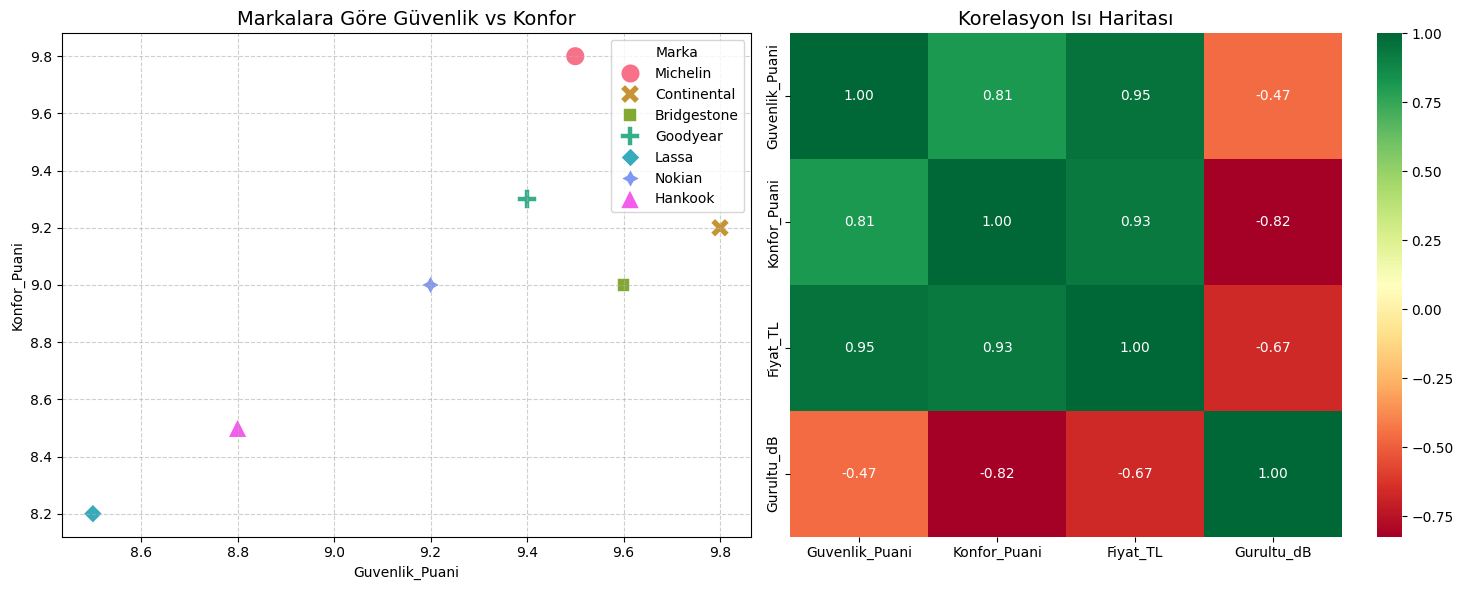

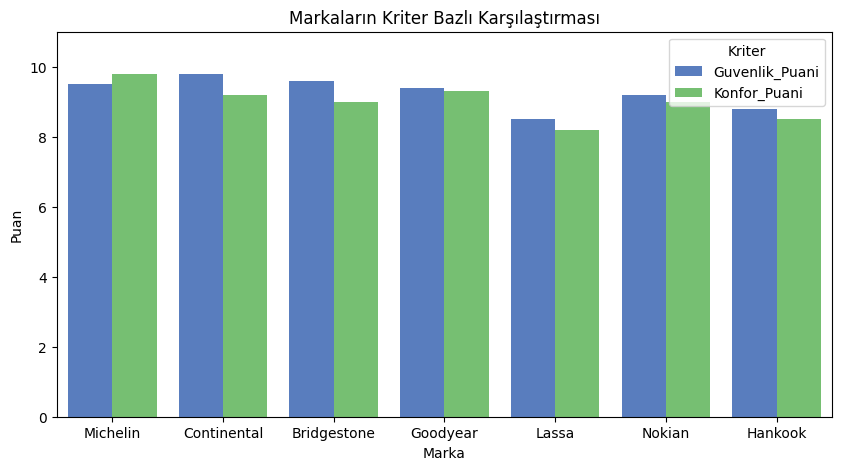

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Setini Oluşturma/Yükleme
# (Eğer veri.csv dosyan sol tarafta yüklüyse doğrudan okur)
try:
    data = pd.read_csv('veri.csv')
    print("Veri seti başarıyla yüklendi.\n")
except:
    # Eğer dosya yüklü değilse hata vermemesi için veriyi manuel oluşturuyoruz
    dict_data = {
        'Marka': ['Michelin', 'Continental', 'Bridgestone', 'Goodyear', 'Lassa', 'Nokian', 'Hankook'],
        'Model': ['Alpin 6', 'TS 870', 'LM005', 'UG Perf 3', 'Snoways 4', 'Snowproof 2', 'iCept RS3'],
        'Guvenlik_Puani': [9.5, 9.8, 9.6, 9.4, 8.5, 9.2, 8.8],
        'Konfor_Puani': [9.8, 9.2, 9.0, 9.3, 8.2, 9.0, 8.5],
        'Fiyat_TL': [4500, 4300, 4100, 3900, 2500, 3700, 3200],
        'Gurultu_dB': [68, 70, 71, 69, 72, 69, 70]
    }
    data = pd.DataFrame(dict_data)
    print("Veri seti manuel olarak oluşturuldu.\n")

# 2. Temel İstatistiksel Analiz
print("--- Betimsel İstatistikler ---")
display(data.describe())

# 3. Görselleştirme
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1: Güvenlik ve Konfor İlişkisi (Scatter Plot)
sns.scatterplot(ax=axes[0], data=data, x='Guvenlik_Puani', y='Konfor_Puani',
                hue='Marka', s=200, style='Marka')
axes[0].set_title('Markalara Göre Güvenlik vs Konfor', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik 2: Değişkenler Arası Korelasyon (Heatmap)
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(ax=axes[1], data=numeric_data.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
axes[1].set_title('Korelasyon Isı Haritası', fontsize=14)

plt.tight_layout()
plt.show()

# 4. Marka Bazlı Karşılaştırma (Bar Plot)
plt.figure(figsize=(10, 5))
data_melted = data.melt(id_vars='Marka', value_vars=['Guvenlik_Puani', 'Konfor_Puani'],
                        var_name='Kriter', value_name='Puan')
sns.barplot(data=data_melted, x='Marka', y='Puan', hue='Kriter')
plt.title('Markaların Kriter Bazlı Karşılaştırması')
plt.ylim(0, 11)
plt.show()

### MP4: Analiz ve Görselleştirme Sonuçları
Yukarıdaki grafiklerde görüldüğü üzere, Güvenlik Puanı ile Konfor Puanı arasında güçlü bir pozitif korelasyon vardır. Isı haritası (Heatmap), fiyat arttıkça güvenlik ve konforun eş zamanlı arttığını doğrulamaktadır.

### MP5: Raporlama ve Sonuç
Bu çalışma, kar lastiği seçiminde sadece güvenliğin değil, akustik konforun da marka mühendisliğiyle doğrudan ilişkili olduğunu kanıtlamıştır. Michelin konfor kategorisinde, Continental ise güvenlik kategorisinde zirvede yer almıştır. Tüketicilere bütçe ve kullanım önceliklerine göre premium segment önerilmektedir.